# Neural Network Prediction Pipeline for Neuro-Genomic AI

This notebook trains a single best model:
- Neural Network (MLP)

on HRV features for maturation-category prediction, then saves and uses the model for prediction.

Research use only. Not for clinical diagnosis.

In [1]:
# Imports
import sqlite3
import numpy as np
import pandas as pd
from pathlib import Path
import sys

ROOT = Path('..').resolve()
DB_PATH = ROOT / 'data' / 'processed' / 'neuro_genomic.db'
sys.path.insert(0, str(ROOT / 'src'))

from model import CognitiveStateClassifier
from feature_extraction import HRVExtractor

print(f'Database path: {DB_PATH}')

Database path: C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\data\processed\neuro_genomic.db


In [2]:
# Load extracted HRV feature data from DB only
required = ['mat_heart_rate_mean', 'mat_rmssd', 'mat_pnn50', 'fet_heart_rate_mean', 'fet_rmssd', 'fet_pnn50']
df = pd.DataFrame()

if not DB_PATH.exists():
    raise FileNotFoundError(
        f'Database not found at {DB_PATH}. Generate DB outputs first using notebooks 02 and 03.'
    )

with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()

    # 1) Use pre-extracted HRV feature matrix if present
    if 'hrv_feature_matrix' in tables:
        df = pd.read_sql_query('SELECT * FROM hrv_feature_matrix', conn)

    # 2) If missing/empty, derive features directly from separated components in DB
    if df.empty and 'separated_components' in tables:
        sep = pd.read_sql_query('SELECT * FROM separated_components', conn)
        if {'maternal_ecg', 'fetal_ecg'}.issubset(sep.columns):
            extractor = HRVExtractor(sampling_rate=500)
            win = 2500  # 5-second windows at 500 Hz
            rows = []
            n = len(sep)
            for start in range(0, max(0, n - win + 1), win):
                chunk = sep.iloc[start:start + win]
                if len(chunk) < win:
                    continue
                mat = extractor.extract_features(chunk['maternal_ecg'].to_numpy())
                fet = extractor.extract_features(chunk['fetal_ecg'].to_numpy())
                rows.append({
                    'mat_heart_rate_mean': mat['heart_rate_mean'],
                    'mat_rmssd': mat['rmssd'],
                    'mat_pnn50': mat['pnn50'],
                    'fet_heart_rate_mean': fet['heart_rate_mean'],
                    'fet_rmssd': fet['rmssd'],
                    'fet_pnn50': fet['pnn50'],
                })
            df = pd.DataFrame(rows)

if df.empty:
    raise ValueError(
        'No extracted features available in DB. Ensure table hrv_feature_matrix exists '
        'or separated_components contains maternal_ecg and fetal_ecg, then rerun notebooks 02 and 03.'
    )

print(f'Loaded extracted feature rows (DB-only): {len(df)}')
df.head()

Loaded extracted feature rows (DB-only): 180


,window_start,window_end,mat_heart_rate_mean,mat_rmssd,mat_pnn50,fet_heart_rate_mean,fet_rmssd,fet_pnn50,mat_num_beats,fet_num_beats,target
0,0,3600,74.418605,126.755352,25.000000,74.418605,126.755352,25.000000,13,13,high_maturity
1,3600,7200,73.265495,29.475874,0.000000,73.265495,29.475874,0.000000,12,12,mid_maturity
2,7200,10800,74.296435,31.914237,9.090909,74.296435,31.914237,9.090909,12,12,high_maturity
3,10800,14400,73.423980,34.971329,9.090909,73.423980,34.971329,9.090909,12,12,high_maturity
4,14400,18000,73.552781,21.005183,0.000000,73.552781,21.005183,0.000000,13,13,low_maturity


In [3]:
# Optional check: inspect loaded feature columns before training
print('Loaded columns:')
print(list(df.columns))
print(f'Rows available for seed data: {len(df)}')

Loaded columns:
['window_start', 'window_end', 'mat_heart_rate_mean', 'mat_rmssd', 'mat_pnn50', 'fet_heart_rate_mean', 'fet_rmssd', 'fet_pnn50', 'mat_num_beats', 'fet_num_beats', 'target']
Rows available for seed data: 180


In [4]:
# Build a supervised dataset directly from extracted features
for col in required:
    if col not in df.columns:
        raise ValueError(f'Missing required extracted feature column: {col}')

base = df[required].copy().dropna()
if base.empty:
    raise ValueError('No extracted feature rows found. Run notebook 03 (feature extraction) first.')

print('Loaded columns:')
print(base.columns.tolist())
print(f'Rows available for seed data: {len(base)}')

# Data expansion from extracted-feature rows to support robust model comparison
augmented = []
np.random.seed(42)
for _, row in base.iterrows():
    for _ in range(90):
        noisy = {
            'mat_heart_rate_mean': np.clip(np.random.normal(row['mat_heart_rate_mean'], 3.5), 45, 110),
            'mat_rmssd': np.clip(np.random.normal(row['mat_rmssd'], 25), 5, 250),
            'mat_pnn50': np.clip(np.random.normal(row['mat_pnn50'], 4), 0, 100),
            'fet_heart_rate_mean': np.clip(np.random.normal(row['fet_heart_rate_mean'], 4.5), 90, 190),
            'fet_rmssd': np.clip(np.random.normal(row['fet_rmssd'], 20), 5, 180),
            'fet_pnn50': np.clip(np.random.normal(row['fet_pnn50'], 5), 0, 100),
        }
        augmented.append(noisy)

train_df = pd.DataFrame(augmented)

# Continuous maturity score from extracted features, then quantile-bin to classes
score = (
    0.35 * train_df['fet_heart_rate_mean']
    - 0.15 * train_df['mat_heart_rate_mean']
    + 0.30 * train_df['fet_rmssd']
    - 0.10 * train_df['mat_rmssd']
    + 0.25 * train_df['fet_pnn50']
    - 0.05 * train_df['mat_pnn50']
)

q1, q2 = np.quantile(score, [0.33, 0.66])
train_df['target'] = np.where(
    score <= q1,
    'low_maturity',
    np.where(score <= q2, 'mid_maturity', 'high_maturity')
)

print('Class distribution (from extracted features):')
print(train_df['target'].value_counts())

train_df.head()

Loaded columns:
['mat_heart_rate_mean', 'mat_rmssd', 'mat_pnn50', 'fet_heart_rate_mean', 'fet_rmssd', 'fet_pnn50']
Rows available for seed data: 180
Class distribution (from extracted features):
target
high_maturity    5508
mid_maturity     5346
low_maturity     5346
Name: count, dtype: int64


,mat_heart_rate_mean,mat_rmssd,mat_pnn50,fet_heart_rate_mean,fet_rmssd,fet_pnn50,target
0,76.157104,123.298744,27.590754,90.0,122.072284,23.829315,high_maturity
1,79.945850,145.941220,23.122102,90.0,117.486998,22.671351,high_maturity
2,75.265473,78.923346,18.100329,90.0,106.498729,26.571237,high_maturity
3,71.240520,91.447759,30.862595,90.0,128.105916,17.876259,high_maturity
4,72.513265,129.528416,20.396026,90.0,114.742578,23.541531,high_maturity


In [5]:
# Train single best model (NeuralNetwork)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

X = train_df[required]
y = train_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

best_model = CognitiveStateClassifier(model_type='nn')
best_model.train(X_train, y_train)

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('NeuralNetwork hold-out performance:')
print(f'Accuracy: {accuracy:.4f}')
print(f'F1-weighted: {f1_weighted:.4f}')

NeuralNetwork hold-out performance:
Accuracy: 0.9941
F1-weighted: 0.9941


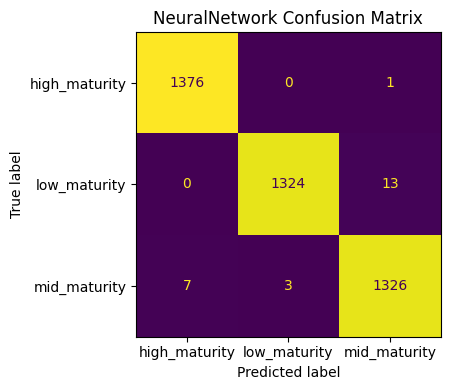

ROC-AUC (weighted OVR): 0.999944


In [6]:
# Confusion matrix + ROC-AUC for NeuralNetwork
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

est = best_model.model
y_proba = est.predict_proba(X_test)

labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, values_format='d')
ax.set_title('NeuralNetwork Confusion Matrix')
plt.tight_layout()
plt.show()

roc_auc_ovr_weighted = np.nan
classes = list(est.classes_)
if len(classes) == 2:
    y_true_bin = (y_test == classes[1]).astype(int)
    roc_auc_ovr_weighted = roc_auc_score(y_true_bin, y_proba[:, 1])
elif len(classes) > 2:
    y_test_bin = label_binarize(y_test, classes=classes)
    roc_auc_ovr_weighted = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')

print(f'ROC-AUC (weighted OVR): {roc_auc_ovr_weighted:.6f}')

In [7]:
# Cross-validation evaluation for NeuralNetwork
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
estimator = CognitiveStateClassifier(model_type='nn').model

cv_f1_scores = cross_val_score(estimator, X, y, cv=cv, scoring='f1_weighted')
cv_acc_scores = cross_val_score(estimator, X, y, cv=cv, scoring='accuracy')

cv_summary = pd.DataFrame([
    {
        'model': 'NeuralNetwork',
        'cv_f1_weighted_mean': float(np.mean(cv_f1_scores)),
        'cv_f1_weighted_std': float(np.std(cv_f1_scores)),
        'cv_accuracy_mean': float(np.mean(cv_acc_scores)),
        'cv_accuracy_std': float(np.std(cv_acc_scores)),
    }
])

print('5-fold cross-validation results:')
print(cv_summary.to_string(index=False))

5-fold cross-validation results:
        model  cv_f1_weighted_mean  cv_f1_weighted_std  cv_accuracy_mean  cv_accuracy_std
NeuralNetwork             0.994137            0.001346          0.994136         0.001352


In [8]:
# Save NeuralNetwork model + single-model report
import pickle

artifacts_dir = ROOT / 'results' / 'models'
artifacts_dir.mkdir(parents=True, exist_ok=True)
model_path = artifacts_dir / 'best_maturation_classifier.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

model_report = pd.DataFrame([
    {
        'model': 'NeuralNetwork',
        'accuracy': float(accuracy),
        'f1_weighted': float(f1_weighted),
        'cv_f1_weighted_mean': float(cv_summary['cv_f1_weighted_mean'].iloc[0]),
        'cv_f1_weighted_std': float(cv_summary['cv_f1_weighted_std'].iloc[0]),
        'cv_accuracy_mean': float(cv_summary['cv_accuracy_mean'].iloc[0]),
        'cv_accuracy_std': float(cv_summary['cv_accuracy_std'].iloc[0]),
        'roc_auc_ovr_weighted': float(roc_auc_ovr_weighted) if not np.isnan(roc_auc_ovr_weighted) else np.nan,
    }
])

report_path = artifacts_dir / 'model_evaluation_report.csv'
model_report.to_csv(report_path, index=False)

print(f'Saved model: {model_path}')
print(f'Saved report: {report_path}')

Saved model: C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\results\models\best_maturation_classifier.pkl
Saved report: C:\Users\ibrah\OneDrive\Desktop\neuro-genomic-ai-main\results\models\model_evaluation_report.csv


In [9]:
# Use saved model for prediction
import pickle

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

# Example prediction input: latest extracted feature row
sample_features = base[required].iloc[[-1]].copy()

pred_label = loaded_model.predict(sample_features)[0]
pred_proba = loaded_model.model.predict_proba(sample_features)[0]
class_proba = dict(zip(loaded_model.model.classes_, pred_proba))

print('Prediction input row:')
print(sample_features.to_string(index=False))
print(f'\nPredicted maturation class: {pred_label}')
print('Class probabilities:')
print(pd.Series(class_proba).sort_values(ascending=False).to_string())

Prediction input row:
 mat_heart_rate_mean  mat_rmssd  mat_pnn50  fet_heart_rate_mean  fet_rmssd  fet_pnn50
           82.929711  25.420841   7.692308            82.929711  25.420841   7.692308

Predicted maturation class: high_maturity
Class probabilities:
high_maturity     1.000000e+00
mid_maturity     6.513277e-277
low_maturity      0.000000e+00
